<a href="https://colab.research.google.com/github/Amarsen123322/mnist-neural-network-numpy/blob/main/2_layer_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install numpy tensorflow matplotlib

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

print("Packages imported successfully")

Packages imported successfully


In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


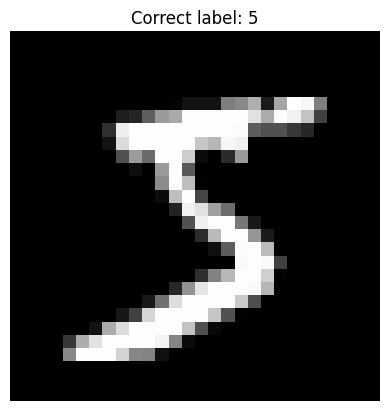

In [6]:
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Correct label: {y_train[0]}")
plt.axis("off")
plt.show()

In [7]:
# Convert each 28 × 28 image into one row containing 784 numbers
x_train_flat = x_train.reshape(60000, 784)
x_test_flat = x_test.reshape(10000, 784)

print("Original training shape:", x_train.shape)
print("Flattened training shape:", x_train_flat.shape)

print("Original test shape:", x_test.shape)
print("Flattened test shape:", x_test_flat.shape)

Original training shape: (60000, 28, 28)
Flattened training shape: (60000, 784)
Original test shape: (10000, 28, 28)
Flattened test shape: (10000, 784)


In [8]:
# Flatten the images and convert the pixel values from 0–255 to 0–1

x_train_ready = x_train.reshape(60000, 784).astype(np.float32) / 255.0
x_test_ready = x_test.reshape(10000, 784).astype(np.float32) / 255.0

print("Training data shape:", x_train_ready.shape)
print("Test data shape:", x_test_ready.shape)

print("Smallest training pixel:", x_train_ready.min())
print("Largest training pixel:", x_train_ready.max())

Training data shape: (60000, 784)
Test data shape: (10000, 784)
Smallest training pixel: 0.0
Largest training pixel: 1.0


In [9]:
print("Original maximum pixel:", x_train[0].max())
print("Normalized maximum pixel:", x_train_ready[0].max())

Original maximum pixel: 255
Normalized maximum pixel: 1.0


In [10]:
print("First 10 training labels:")
print(y_train[:10])

First 10 training labels:
[5 0 4 1 9 2 1 3 1 4]


In [11]:
# Create empty tables filled with zeros

y_train_ready = np.zeros((60000, 10), dtype=np.float32)
y_test_ready = np.zeros((10000, 10), dtype=np.float32)

# Put a 1 in the position of the correct digit

y_train_ready[np.arange(60000), y_train] = 1.0
y_test_ready[np.arange(10000), y_test] = 1.0

print("Training labels shape:", y_train_ready.shape)
print("Test labels shape:", y_test_ready.shape)

Training labels shape: (60000, 10)
Test labels shape: (10000, 10)


In [12]:
print("Original label:")
print(y_train[0])

print("\nOne-hot label:")
print(y_train_ready[0])

Original label:
5

One-hot label:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [13]:
# Make the random starting values repeatable
np.random.seed(42)

# Number of neurons in each part of the network
input_size = 784
hidden_size = 128
output_size = 10

# Weights and biases from input layer to hidden layer
W1 = np.random.randn(input_size, hidden_size).astype(np.float32)
W1 = W1 * np.sqrt(2.0 / input_size)

b1 = np.zeros((1, hidden_size), dtype=np.float32)

# Weights and biases from hidden layer to output layer
W2 = np.random.randn(hidden_size, output_size).astype(np.float32)
W2 = W2 * np.sqrt(2.0 / hidden_size)

b2 = np.zeros((1, output_size), dtype=np.float32)

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (784, 128)
b1 shape: (1, 128)
W2 shape: (128, 10)
b2 shape: (1, 10)


In [14]:
# ReLU activation function
def relu(x):
    return np.maximum(0, x)


# Softmax activation function
def softmax(x):
    # Subtract the largest value to prevent very large numbers
    shifted_x = x - np.max(x, axis=1, keepdims=True)

    exponentials = np.exp(shifted_x)

    probabilities = exponentials / np.sum(
        exponentials,
        axis=1,
        keepdims=True
    )

    return probabilities


print("Activation functions created successfully")

Activation functions created successfully


In [15]:
test_output = np.array([[1.0, 2.0, 3.0]])

test_probabilities = softmax(test_output)

print("Probabilities:")
print(test_probabilities)

print("Total:")
print(test_probabilities.sum())

Probabilities:
[[0.09003057 0.24472847 0.66524096]]
Total:
0.9999999999999999


In [16]:
def forward_pass(x):
    # First layer: input to hidden layer
    z1 = x @ W1 + b1

    # Apply ReLU
    a1 = relu(z1)

    # Second layer: hidden layer to output layer
    z2 = a1 @ W2 + b2

    # Convert output numbers into probabilities
    probabilities = softmax(z2)

    return z1, a1, z2, probabilities


print("Forward-pass function created successfully")

Forward-pass function created successfully


In [17]:
# Select the first prepared training image
first_image = x_train_ready[0:1]

# Send it through the network
z1, a1, z2, probabilities = forward_pass(first_image)

print("Input shape:", first_image.shape)
print("Hidden-layer shape:", a1.shape)
print("Output shape:", probabilities.shape)

Input shape: (1, 784)
Hidden-layer shape: (1, 128)
Output shape: (1, 10)


In [18]:
print("Probabilities for digits 0 to 9:")
print(probabilities)

Probabilities for digits 0 to 9:
[[0.14479961 0.0925005  0.09725679 0.04483728 0.06972212 0.13210605
  0.0556922  0.14834432 0.07805109 0.13669003]]


In [19]:
predicted_digit = np.argmax(probabilities)

print("Network prediction:", predicted_digit)
print("Correct answer:", y_train[0])

Network prediction: 7
Correct answer: 5


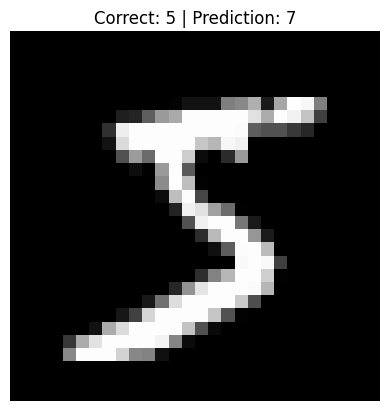

In [20]:
plt.imshow(x_train[0], cmap="gray")
plt.title(
    f"Correct: {y_train[0]} | Prediction: {predicted_digit}"
)
plt.axis("off")
plt.show()

In [21]:
def cross_entropy_loss(probabilities, correct_labels):
    # Prevent errors caused by log(0)
    safe_probabilities = np.clip(
        probabilities,
        1e-12,
        1.0
    )

    loss = -np.sum(
        correct_labels * np.log(safe_probabilities)
    ) / correct_labels.shape[0]

    return loss


print("Loss function created successfully")

Loss function created successfully


In [22]:
# The prepared correct label for the first image
first_correct_label = y_train_ready[0:1]

# Calculate how wrong the prediction is
first_loss = cross_entropy_loss(
    probabilities,
    first_correct_label
)

print("Correct digit:", y_train[0])
print("Predicted digit:", np.argmax(probabilities))
print("Loss:", first_loss)

Correct digit: 5
Predicted digit: 7
Loss: 2.0241502910823286


In [23]:
# The prepared correct label for the first image
first_correct_label = y_train_ready[0:1]

# Calculate how wrong the prediction is
first_loss = cross_entropy_loss(
    probabilities,
    first_correct_label
)

print("Correct digit:", y_train[0])
print("Predicted digit:", np.argmax(probabilities))
print("Loss:", first_loss)

Correct digit: 5
Predicted digit: 7
Loss: 2.0241502910823286


In [24]:
correct_digit = y_train[0]

correct_digit_probability = probabilities[0, correct_digit]

print("Correct digit:", correct_digit)
print("Probability given to the correct digit:", correct_digit_probability)

Correct digit: 5
Probability given to the correct digit: 0.13210604719708727


In [25]:
def relu_derivative(x):
    # Positive values become 1
    # Zero or negative values become 0
    return (x > 0).astype(np.float32)


print("ReLU derivative created successfully")

ReLU derivative created successfully


In [26]:
def backward_pass(x, correct_labels, z1, a1, probabilities):
    # Number of images in this batch
    batch_size = x.shape[0]

    # -----------------------------
    # Output layer gradients
    # -----------------------------

    dz2 = (probabilities - correct_labels) / batch_size

    dW2 = a1.T @ dz2

    db2 = np.sum(
        dz2,
        axis=0,
        keepdims=True
    )

    # -----------------------------
    # Hidden layer gradients
    # -----------------------------

    da1 = dz2 @ W2.T

    dz1 = da1 * relu_derivative(z1)

    dW1 = x.T @ dz1

    db1 = np.sum(
        dz1,
        axis=0,
        keepdims=True
    )

    return dW1, db1, dW2, db2


print("Backpropagation function created successfully")

Backpropagation function created successfully


In [27]:
dW1, db1, dW2, db2 = backward_pass(
    first_image,
    first_correct_label,
    z1,
    a1,
    probabilities
)

print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)
print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)

dW1 shape: (784, 128)
db1 shape: (1, 128)
dW2 shape: (128, 10)
db2 shape: (1, 10)


In [28]:
old_loss = first_loss

print("Loss before updating:", old_loss)

Loss before updating: 2.0241502910823286


In [29]:
learning_rate = 0.1

# Update the first layer
W1 = W1 - learning_rate * dW1
b1 = b1 - learning_rate * db1

# Update the second layer
W2 = W2 - learning_rate * dW2
b2 = b2 - learning_rate * db2

print("Weights and biases updated successfully")

Weights and biases updated successfully


In [30]:
new_z1, new_a1, new_z2, new_probabilities = forward_pass(
    first_image
)

new_loss = cross_entropy_loss(
    new_probabilities,
    first_correct_label
)

print("Loss before update:", old_loss)
print("Loss after update:", new_loss)

print("Old prediction:", np.argmax(probabilities))
print("New prediction:", np.argmax(new_probabilities))
print("Correct answer:", y_train[0])

Loss before update: 2.0241502910823286
Loss after update: 0.03590652236112034
Old prediction: 7
New prediction: 5
Correct answer: 5


In [31]:
# Reset the neural network before full training

np.random.seed(42)

input_size = 784
hidden_size = 128
output_size = 10

W1 = np.random.randn(input_size, hidden_size).astype(np.float32)
W1 = W1 * np.sqrt(2.0 / input_size)

b1 = np.zeros((1, hidden_size), dtype=np.float32)

W2 = np.random.randn(hidden_size, output_size).astype(np.float32)
W2 = W2 * np.sqrt(2.0 / hidden_size)

b2 = np.zeros((1, output_size), dtype=np.float32)

print("Network reset successfully")

Network reset successfully


In [32]:
# Training settings

epochs = 5
batch_size = 128
learning_rate = 0.1

number_of_training_images = x_train_ready.shape[0]

print("Training started...\n")


for epoch in range(epochs):

    # Shuffle the image order at the beginning of each epoch
    shuffled_indices = np.random.permutation(
        number_of_training_images
    )

    x_shuffled = x_train_ready[shuffled_indices]
    y_shuffled = y_train_ready[shuffled_indices]

    original_labels_shuffled = y_train[shuffled_indices]

    total_loss = 0.0
    total_correct = 0

    # Go through the training data in batches
    for start in range(
        0,
        number_of_training_images,
        batch_size
    ):

        end = start + batch_size

        x_batch = x_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        label_batch = original_labels_shuffled[start:end]

        # Step 1: Forward propagation
        z1, a1, z2, probabilities = forward_pass(x_batch)

        # Step 2: Calculate loss
        batch_loss = cross_entropy_loss(
            probabilities,
            y_batch
        )

        # Step 3: Backpropagation
        dW1, db1, dW2, db2 = backward_pass(
            x_batch,
            y_batch,
            z1,
            a1,
            probabilities
        )

        # Step 4: Update weights and biases
        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1

        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2

        # Add this batch's loss
        current_batch_size = x_batch.shape[0]

        total_loss += batch_loss * current_batch_size

        # Count correct predictions
        batch_predictions = np.argmax(
            probabilities,
            axis=1
        )

        total_correct += np.sum(
            batch_predictions == label_batch
        )

    # Calculate results for this epoch
    average_loss = total_loss / number_of_training_images

    training_accuracy = (
        total_correct / number_of_training_images
    )

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Accuracy: {training_accuracy * 100:.2f}%"
    )


print("\nTraining completed")

Training started...

Epoch 1/5 | Loss: 0.4677 | Accuracy: 87.31%
Epoch 2/5 | Loss: 0.2618 | Accuracy: 92.51%
Epoch 3/5 | Loss: 0.2115 | Accuracy: 94.10%
Epoch 4/5 | Loss: 0.1777 | Accuracy: 94.95%
Epoch 5/5 | Loss: 0.1535 | Accuracy: 95.68%

Training completed


In [33]:
# Send all test images through the trained network

test_z1, test_a1, test_z2, test_probabilities = forward_pass(
    x_test_ready
)

# Get the predicted digit for every test image
test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

# Calculate test accuracy
number_correct = np.sum(test_predictions == y_test)

test_accuracy = number_correct / len(y_test)

# Calculate test loss
test_loss = cross_entropy_loss(
    test_probabilities,
    y_test_ready
)

print("Test loss:", test_loss)
print("Correct predictions:", number_correct)
print("Total test images:", len(y_test))
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Test loss: 0.14355003316321266
Correct predictions: 9583
Total test images: 10000
Test accuracy: 95.83%


Network prediction: 7
Correct answer: 7


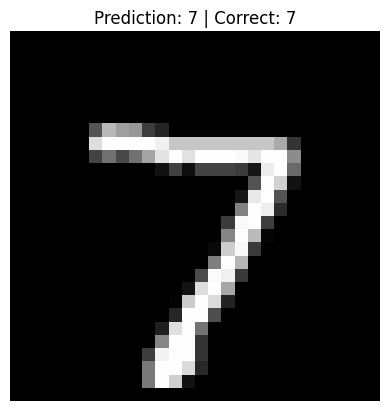

In [34]:
# Choose a test image number

image_number = 0

print("Network prediction:", test_predictions[image_number])
print("Correct answer:", y_test[image_number])

plt.imshow(x_test[image_number], cmap="gray")
plt.title(
    f"Prediction: {test_predictions[image_number]} | "
    f"Correct: {y_test[image_number]}"
)
plt.axis("off")
plt.show()

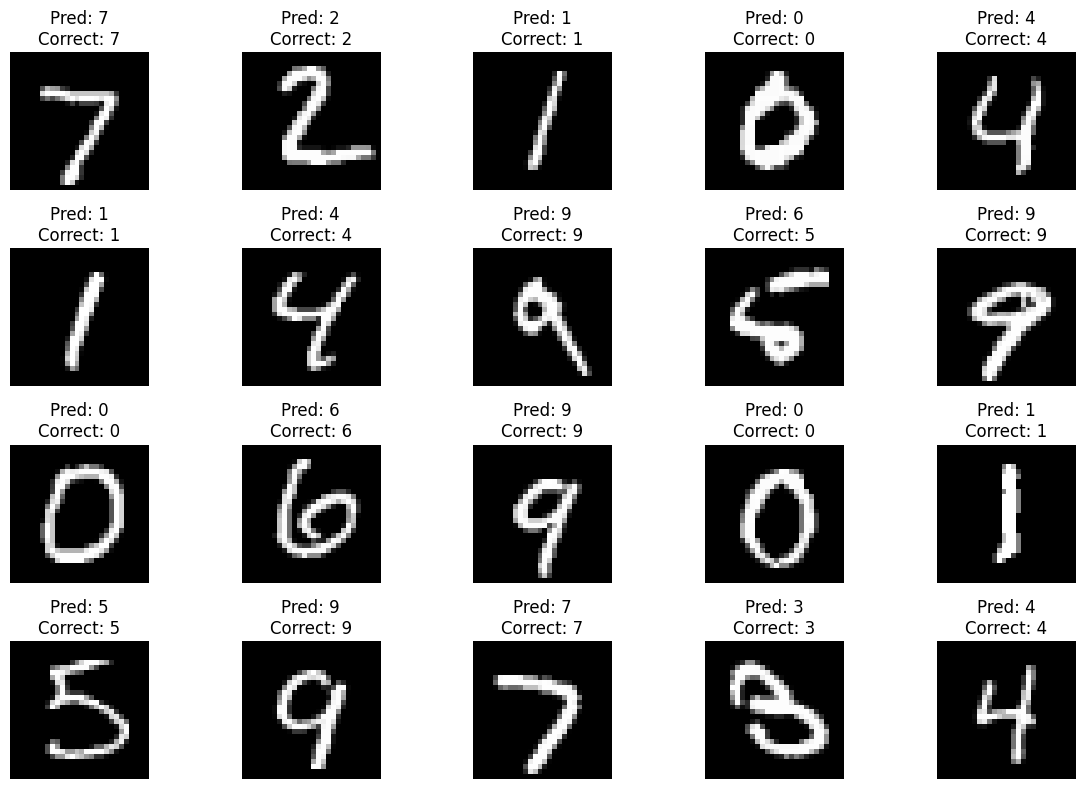

In [35]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[i], cmap="gray")

    predicted = test_predictions[i]
    correct = y_test[i]

    plt.title(
        f"Pred: {predicted}\nCorrect: {correct}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# Find the positions where the prediction was wrong

wrong_indices = np.where(
    test_predictions != y_test
)[0]

print("Number of incorrect predictions:", len(wrong_indices))
print("First incorrect image positions:", wrong_indices[:10])

Number of incorrect predictions: 417
First incorrect image positions: [  8  33 124 149 233 241 247 259 318 320]


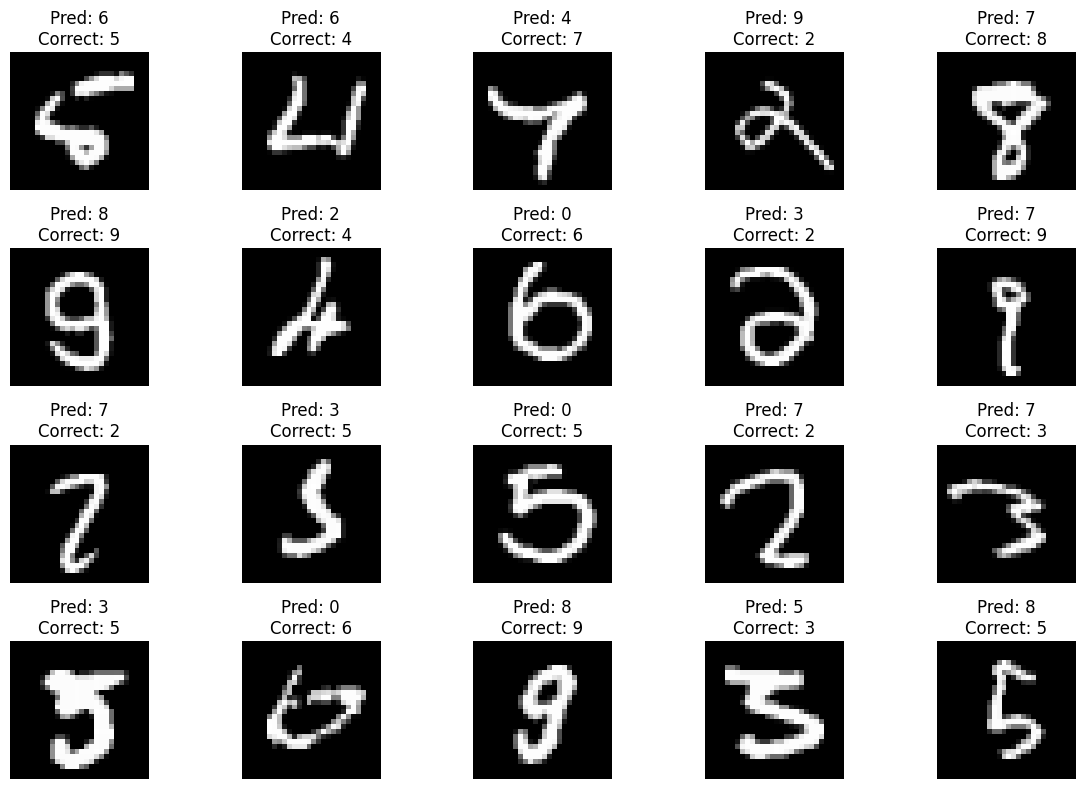

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(20):
    image_index = wrong_indices[i]

    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[image_index], cmap="gray")

    predicted = test_predictions[image_index]
    correct = y_test[image_index]

    plt.title(
        f"Pred: {predicted}\nCorrect: {correct}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()